## ACT 1
My Roll number = 24UG00307
Therefore, last four digits W,X,Y,Z = 0,3,0,7

So the given constraint R = digital root of(0+3+0+7) = 1

Also given a f(x)=((x^3)/3)-(R(x^2))+((R^2)-1)x
so if we take derivative of f(x) for the critical points

f'(x)=x^2−2Rx+(R^2−1)=0 ==>Using quadratic formula:
solving this to get crital points x=R-1 and x=R+1

so the month range is [0,2]

assuming that months start from 0,1,2 ==> A three month analysis window 

so our dataset must be from January, February, MArch

CONCLUSION ON ACT 1:
Based on the given constarint we got to know that we need to analyse the case for three month window

The problem states that:
- No major drop in revenue or trip count is observed
- However, system behavior feels unstable

This implies: The system is not failing, but drifting.

In [2]:
#################################################################################################################################

## ACT 2

Final Dataset Justification

The objective is to detect subtle inefficiencies within a single operational system.

1.Green Taxi data is geographically constrained and does not represent the full urban system.They are not operated in inner core part of nyc

2.FHV and High-Volume FHV datasets operate under fundamentally different models:
- Dynamic pricing
- App-based dispatch
- Different demand patterns

Including these would introduce structural inconsistencies, making it difficult to distinguish true system inefficiencies from model differences.

Yellow Taxi data is selected because:
- It follows a standardized metered pricing system
- It has consistent trip-level features
- It represents a stable and well-defined operational system

This ensures that any detected variability reflects actual system behavior rather than differences in business models.

SO therefoe the selcted DataSets are 
yellow_trip_data of 2026 of three months January, Febraury, March



In [1]:
import pandas as pd

files = [
    "yellow_tripdata_2026-01.parquet",
    "yellow_tripdata_2026-02.parquet",
    "yellow_tripdata_2026-03.parquet"
]

df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

df.shape

(11077206, 20)

In [2]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='str')

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11077206 entries, 0 to 11077205
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64 

## Defining a Real Trip

A trip is considered valid if it satisfies the following conditions:

1. Trip Distance > 0
2. Total Fare > 0
3. Dropoff Time > Pickup Time
4. Trip Duration is within a reasonable range
5. Passenger Count ≥ 1
6. No critical missing values

These rules ensure that only logically consistent trips are included in the analysis.

In [6]:
df = df[
    (df['tpep_pickup_datetime'].dt.year == 2026) &
    (df['tpep_pickup_datetime'].dt.month.isin([1, 2, 3]))
].copy()

In [7]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11077201,2,2026-03-31 23:10:43,2026-03-31 23:33:02,NaN,8.47,NaN,None,13,263,0,50.14,0.00,0.5,0.00,0.0,1.0,60.37,NaN,NaN,0.75
11077202,2,2026-03-31 23:41:22,2026-03-31 23:52:36,NaN,1.99,NaN,None,24,42,0,12.32,0.00,0.5,0.00,0.0,1.0,13.82,NaN,NaN,0.00
11077203,2,2026-03-31 23:39:38,2026-04-01 00:13:44,NaN,10.21,NaN,None,62,237,0,47.95,0.00,0.5,0.00,0.0,1.0,52.70,NaN,NaN,0.75
11077204,2,2026-03-31 23:57:57,2026-04-01 00:29:33,NaN,7.87,NaN,None,61,141,0,49.93,0.00,0.5,0.00,0.0,1.0,53.93,NaN,NaN,0.00


In [11]:
df['tpep_pickup_datetime'].dt.year.unique()

array([2026], dtype=int32)

In [12]:
df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['trip_duration'] = (
    df['dropoff_datetime'] - df['pickup_datetime']
).dt.total_seconds() / 60  # minutes

In [13]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_datetime,dropoff_datetime,trip_duration
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,3.66,0.0,1.0,15.86,2.5,0.0,0.00,2026-01-01 00:54:04,2026-01-01 00:59:37,5.550000
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,0.00,0.0,1.0,13.65,2.5,0.0,0.75,2026-01-01 00:34:04,2026-01-01 00:39:47,5.716667
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,2.50,0.0,1.0,18.95,2.5,0.0,0.75,2026-01-01 00:57:06,2026-01-01 01:05:59,8.883333
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,11.11,0.0,1.0,55.56,2.5,0.0,0.75,2026-01-01 00:15:22,2026-01-01 00:58:10,42.800000
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,3.85,0.0,1.0,23.10,2.5,0.0,0.75,2026-01-01 00:27:13,2026-01-01 00:40:43,13.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11077201,2,2026-03-31 23:10:43,2026-03-31 23:33:02,NaN,8.47,NaN,None,13,263,0,...,0.00,0.0,1.0,60.37,NaN,NaN,0.75,2026-03-31 23:10:43,2026-03-31 23:33:02,22.316667
11077202,2,2026-03-31 23:41:22,2026-03-31 23:52:36,NaN,1.99,NaN,None,24,42,0,...,0.00,0.0,1.0,13.82,NaN,NaN,0.00,2026-03-31 23:41:22,2026-03-31 23:52:36,11.233333
11077203,2,2026-03-31 23:39:38,2026-04-01 00:13:44,NaN,10.21,NaN,None,62,237,0,...,0.00,0.0,1.0,52.70,NaN,NaN,0.75,2026-03-31 23:39:38,2026-04-01 00:13:44,34.100000
11077204,2,2026-03-31 23:57:57,2026-04-01 00:29:33,NaN,7.87,NaN,None,61,141,0,...,0.00,0.0,1.0,53.93,NaN,NaN,0.00,2026-03-31 23:57:57,2026-04-01 00:29:33,31.600000


In [14]:
df[df['trip_duration']<0].shape
#negative duration rides are Impossible 

(5, 23)

In [15]:
df = df[df['trip_duration'] >= 0].copy()

In [16]:
df[df['trip_duration']<0].shape #negative duration are removed

(0, 23)

In [17]:
#Trips zero distance
df[df['trip_distance'] == 0].shape

#Because thhere is no neghative distance rows
#Zero distance may indicate for very short trip which may not be recorded or might be neglected due to sensor errors or they might have cancelled the ride.

(370198, 23)

In [18]:
#Trips with zero or negative fare
df[df['total_amount'] < 0].shape

(88578, 23)

In [19]:
#Impossible time (drop before pickup)
df[df['trip_duration'] == 0].shape
#again if the trip

(134796, 23)

In [20]:
#Extreme durations (suspicious)
df[df['trip_duration'] > 300].shape  # > 5 hours

(3550, 23)

In [21]:
#Passenger issues
df[df['passenger_count'] <= 0].shape #if there is no passenger then hiow is that ride evn valid

(40638, 23)

In [22]:
df = df[df['passenger_count'] >= 0].copy() #removed passengers with -ve or zero rides

In [23]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_datetime,dropoff_datetime,trip_duration
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,3.66,0.0,1.0,15.86,2.5,0.0,0.00,2026-01-01 00:54:04,2026-01-01 00:59:37,5.550000
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,0.00,0.0,1.0,13.65,2.5,0.0,0.75,2026-01-01 00:34:04,2026-01-01 00:39:47,5.716667
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,2.50,0.0,1.0,18.95,2.5,0.0,0.75,2026-01-01 00:57:06,2026-01-01 01:05:59,8.883333
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,11.11,0.0,1.0,55.56,2.5,0.0,0.75,2026-01-01 00:15:22,2026-01-01 00:58:10,42.800000
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,3.85,0.0,1.0,23.10,2.5,0.0,0.75,2026-01-01 00:27:13,2026-01-01 00:40:43,13.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10131453,2,2026-03-31 23:17:20,2026-03-31 23:27:29,1.0,2.29,1.0,N,236,163,1,...,4.64,0.0,1.0,23.19,2.5,0.0,0.75,2026-03-31 23:17:20,2026-03-31 23:27:29,10.150000
10131454,2,2026-03-31 23:30:28,2026-03-31 23:40:04,1.0,1.90,1.0,N,163,246,1,...,3.43,0.0,1.0,20.58,2.5,0.0,0.75,2026-03-31 23:30:28,2026-03-31 23:40:04,9.600000
10131455,2,2026-03-31 23:15:21,2026-03-31 23:30:37,1.0,2.62,1.0,N,142,107,1,...,2.22,0.0,1.0,24.27,2.5,0.0,0.75,2026-03-31 23:15:21,2026-03-31 23:30:37,15.266667
10131456,2,2026-03-31 23:02:01,2026-03-31 23:06:57,1.0,1.03,1.0,N,170,100,1,...,0.00,0.0,1.0,12.95,2.5,0.0,0.75,2026-03-31 23:02:01,2026-03-31 23:06:57,4.933333


In [24]:
df = df[df['trip_distance'] < 200] #removed rows where rides are grater that 200 miles bcz hardly any ride in nyc goes beyond 200 miles

In [25]:
df = df[df['trip_duration'] < 1440]  # < 24 hours #NO ride will be for 24 hours

In [26]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_datetime,dropoff_datetime,trip_duration
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,3.66,0.0,1.0,15.86,2.5,0.0,0.00,2026-01-01 00:54:04,2026-01-01 00:59:37,5.550000
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,0.00,0.0,1.0,13.65,2.5,0.0,0.75,2026-01-01 00:34:04,2026-01-01 00:39:47,5.716667
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,2.50,0.0,1.0,18.95,2.5,0.0,0.75,2026-01-01 00:57:06,2026-01-01 01:05:59,8.883333
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,11.11,0.0,1.0,55.56,2.5,0.0,0.75,2026-01-01 00:15:22,2026-01-01 00:58:10,42.800000
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,3.85,0.0,1.0,23.10,2.5,0.0,0.75,2026-01-01 00:27:13,2026-01-01 00:40:43,13.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10131453,2,2026-03-31 23:17:20,2026-03-31 23:27:29,1.0,2.29,1.0,N,236,163,1,...,4.64,0.0,1.0,23.19,2.5,0.0,0.75,2026-03-31 23:17:20,2026-03-31 23:27:29,10.150000
10131454,2,2026-03-31 23:30:28,2026-03-31 23:40:04,1.0,1.90,1.0,N,163,246,1,...,3.43,0.0,1.0,20.58,2.5,0.0,0.75,2026-03-31 23:30:28,2026-03-31 23:40:04,9.600000
10131455,2,2026-03-31 23:15:21,2026-03-31 23:30:37,1.0,2.62,1.0,N,142,107,1,...,2.22,0.0,1.0,24.27,2.5,0.0,0.75,2026-03-31 23:15:21,2026-03-31 23:30:37,15.266667
10131456,2,2026-03-31 23:02:01,2026-03-31 23:06:57,1.0,1.03,1.0,N,170,100,1,...,0.00,0.0,1.0,12.95,2.5,0.0,0.75,2026-03-31 23:02:01,2026-03-31 23:06:57,4.933333


In [27]:
#################################################################################################################################

<h4>ACT 3</h4>

## Hypothesis:
Changes in average fare are primarily driven by mechanical pricing factors 
(such as trip distance), rather than behavioral changes.


In [28]:
df['date'] = df['pickup_datetime'].dt.date

daily = df.groupby('date').agg({
    'total_amount': 'mean',
    'trip_distance': 'mean',
    'trip_duration': 'mean'
}).reset_index()

daily.rename(columns={
    'total_amount': 'avg_fare',
    'trip_distance': 'avg_distance',
    'trip_duration': 'avg_duration'
}, inplace=True)

daily.head()

,date,avg_fare,avg_distance,avg_duration
0,2026-01-01,29.465792,3.777238,14.382565
1,2026-01-02,29.534822,3.807041,16.454893
2,2026-01-03,28.584166,3.668966,15.412865
3,2026-01-04,30.884643,4.309212,15.395285
4,2026-01-05,30.012680,4.097014,17.711456


In [29]:
daily[['avg_fare', 'avg_distance', 'avg_duration']].corr()

,avg_fare,avg_distance,avg_duration
avg_fare,1.000000,0.782803,0.642718
avg_distance,0.782803,1.000000,0.101684
avg_duration,0.642718,0.101684,1.000000


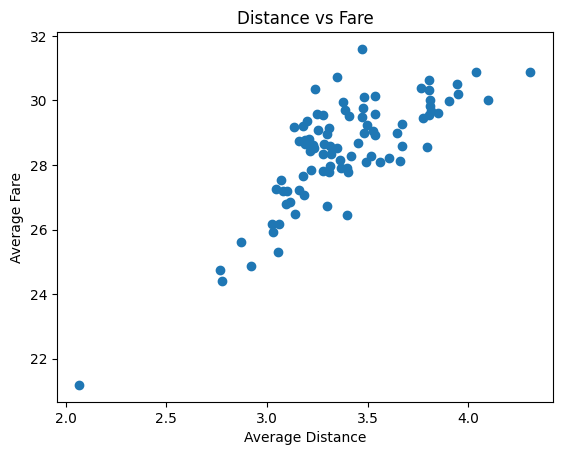

In [31]:
import matplotlib.pyplot as plt

plt.scatter(daily['avg_distance'], daily['avg_fare'])
plt.xlabel("Average Distance")
plt.ylabel("Average Fare")
plt.title("Distance vs Fare")
plt.show()

## Statistical Evidence

The correlation between average distance and average fare is 0.78, 
indicating a strong positive relationship.

This suggests that fare is largely determined by trip distance, 
consistent with a meter-based pricing system.

The scatter plot further supports this, showing a clear upward trend 
between distance and fare.

## Alternative Explanation

An alternative explanation is that behavioral factors influence fare.

For example:
- Passengers may choose shorter or longer trips
- Drivers may alter routes
- External conditions (traffic, demand) may affect pricing

If this were dominant, we would expect weaker correlation between 
distance and fare.

## Comparison of Explanations

The strong correlation (0.78) indicates that mechanical pricing plays a dominant role.

However, the correlation is not perfect, suggesting that behavioral or external 
factors also contribute to variations in fare.

Thus, while mechanical factors explain most of the pattern, 
they do not fully account for all observed variability.

## Final Conclusion

The system appears to be primarily mechanical, with fare largely determined by distance.

However, the presence of unexplained variation indicates that 
behavioral factors or inefficiencies may still exist.

This suggests that the system is not fully unstable, 
but may exhibit localized zones of stress.

## Conditions That Would Change This Conclusion

The conclusion would shift toward a behavioral explanation if:

- The correlation between distance and fare were weak
- Significant variation in fare occurred for similar distances
- External factors (such as surge pricing or policy changes) dominated pricing

In such cases, behavior would play a larger role than mechanical rules.

#THIS SYSTEM IS NOT BROKEN IT IS FUNCTIONING MECHANICALLY BUT THERE IS SOMETHING WHICH IS MAKING THIS GO BEYOND WHICH CAN BE STRESS

An additional observation is the weak correlation (0.10) between distance and duration.

This suggests that travel time is not strongly dependent on distance, 
which may indicate variability due to traffic conditions or routing inefficiencies.

This could be an early signal of system stress.

In [33]:
##############################################################################################################################

## ACT 4


In [35]:
daily = df.groupby(df['pickup_datetime'].dt.date).agg({
    'total_amount': 'mean',
    'trip_distance': 'mean',
    'trip_duration': 'mean',
    'pickup_datetime': 'count'
}).rename(columns={'pickup_datetime': 'trip_count'}).reset_index()

daily.columns = ['date', 'avg_fare', 'avg_distance', 'avg_duration', 'trip_count']

In [36]:
df['hour'] = df['pickup_datetime'].dt.hour

hourly = df.groupby('hour').agg({
    'total_amount': 'mean',
    'trip_distance': 'mean',
    'trip_duration': 'mean',
    'pickup_datetime': 'count'
}).rename(columns={'pickup_datetime': 'trip_count'}).reset_index()

hourly.columns = ['hour', 'avg_fare', 'avg_distance', 'avg_duration', 'trip_count']

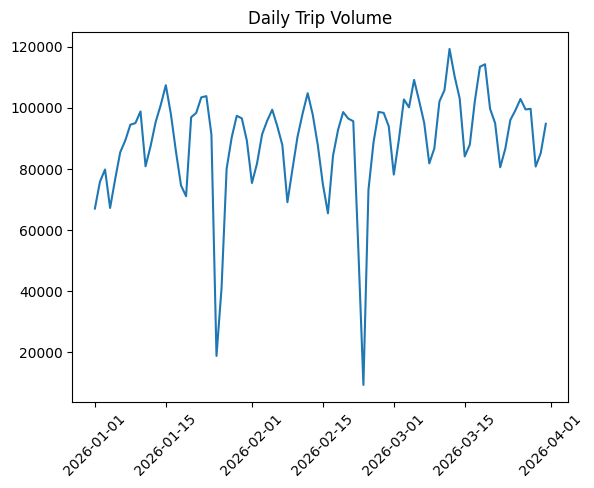

In [37]:
#Daily Trip Count (rhythm over time)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(daily['date'], daily['trip_count'])
plt.xticks(rotation=45)
plt.title("Daily Trip Volume")
plt.show()

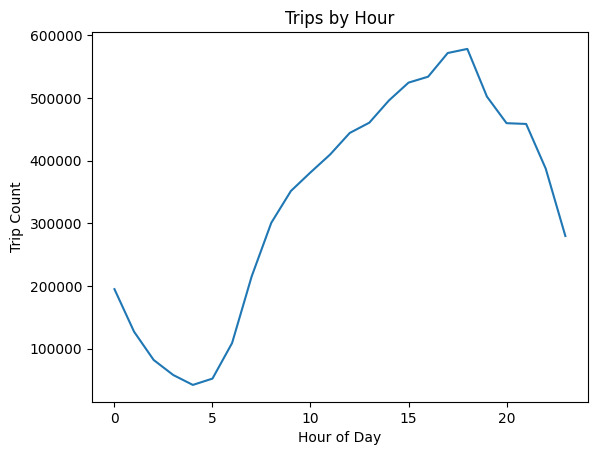

In [38]:
#Hourly Pattern (THIS reveals city rhythm)
plt.figure()
plt.plot(hourly['hour'], hourly['trip_count'])
plt.title("Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.show()

## hour vs day trip count
This shows that there is a rythm in thje city telling that people might use it to get to home from their workplace because it shows a rise in late evenings and dip in some weekend and holidays

Also shows that hourly it is cyclical values and breaks in weekends or holidyas

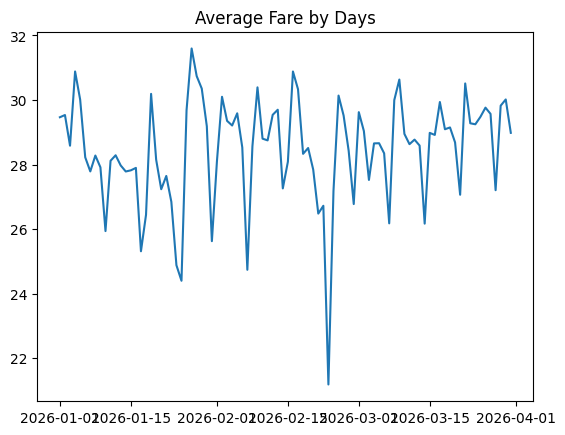

In [40]:
#daily Fare Pattern
plt.figure()
plt.plot(daily['date'], daily['avg_fare'])
plt.title("Average Fare by Days")
plt.show()

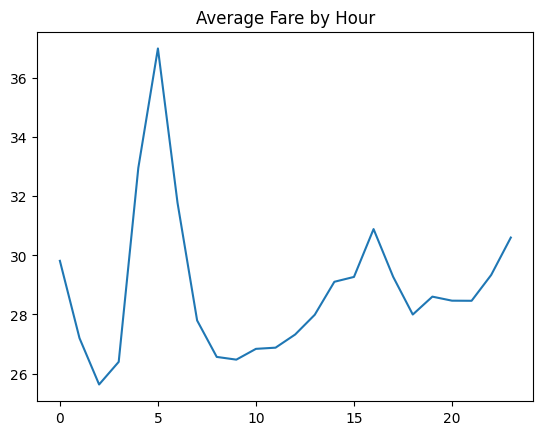

In [39]:
#Hourly Fare Pattern
plt.figure()
plt.plot(hourly['hour'], hourly['avg_fare'])
plt.title("Average Fare by Hour")
plt.show()

## Hourly vs Day fare comparision
this shows that the mornings have high price bcz of the demand of peopole to go to their workplace and their work-off time mioght be diffrent so then the demand and supply balances so there is no price hick 
this can also show a behavioural increase in the price but that data is so vast to confirm it.

<br>


HOWEVER,
The observed patterns depend on the level of aggregation.

At the hourly level, clear cycles emerge.
At the daily level, some of these patterns smooth out.

This indicates that certain patterns are scale-dependent and 
may not represent fundamental system behavior.

In [43]:
daily.to_csv("daily_data.csv", index=False)
hourly.to_csv("hourly_data.csv", index=False)
df.to_csv("clean_data_sample.csv", index=False)  

In [44]:
#########################################################################################################################################

## Final Conclusion

This investigation was conducted to determine whether the NYC taxi system is functioning normally or quietly drifting into inefficiency.

The analysis was restricted to a defined time window (January–March 2026), derived analytically, and focused on Yellow Taxi trip data to ensure consistency and comparability.

### Data Reliability

The dataset contained inconsistencies, including invalid timestamps, unrealistic values, and edge-case records.
Rather than aggressively removing data, only logically impossible records (such as negative trip durations) were eliminated.

Other anomalies were retained, as they may represent real-world operational behavior rather than errors.

This approach ensures that the dataset remains both clean and representative of actual system conditions.

---

### System Behavior

The system exhibits strong mechanical structure:

* A strong positive relationship exists between trip distance and fare
* This confirms that pricing largely follows a predictable, meter-based model

However, this relationship is not perfect:

* Variability in fare for similar distances suggests the presence of additional factors
* Weak correlation between distance and duration indicates inconsistencies in travel time, likely due to traffic or routing conditions

This suggests that while the system is fundamentally structured, it is not perfectly efficient.

---

### Temporal Patterns and System Rhythm

When aggregated over time, the system reveals clear cyclical patterns:

* Trip volume follows consistent daily and hourly rhythms
* These patterns align with expected human activity cycles (e.g., commuting hours)

However, not all observed patterns persist:

* Some fluctuations disappear when viewed at different aggregation levels
* This indicates that certain patterns are artifacts of observation rather than true system behavior

Thus, the system demonstrates a **stable cyclical structure**, with localized irregularities.

---

### Zones of Stability and Stress

The system is not uniformly stable.

* Stability is observed where relationships between key variables (fare, distance, time) behave consistently
* Stress appears in localized deviations, particularly where expected relationships weaken or fluctuate

Examples include:

* Inconsistent travel times relative to distance
* Variability in fare beyond what distance alone explains

These do not indicate system failure, but rather **early signs of inefficiency or pressure**

---

### Decision Impact and Uncertainty

Simulated scenarios show that system outcomes vary depending on decisions, such as changes in fare levels.

Importantly:

* Outcomes are not deterministic
* A range of possible results must be considered

This highlights that:

> Decisions in this system operate under uncertainty, not certainty

---

### Risk of Misinterpretation

A critical finding of this investigation is that incorrect conclusions can easily be drawn from the same data.

Examples include:

* Interpreting rising fares as improved performance without accounting for distance
* Treating all anomalies as errors rather than potential signals
* Mixing incompatible datasets, leading to misleading patterns

This demonstrates that:

> Misinterpretation poses a significant risk, equal to or greater than inaction

---

### Final Assessment

The NYC taxi system is **not failing**, but it is **not perfectly stable**.

It operates as a structured, cyclical system with a strong mechanical foundation,
but shows localized inefficiencies and signs of stress.

These inefficiencies are subtle and may not be visible through traditional metrics alone.

---

### Closing Statement

The system can be trusted at a high level,
but its behavior must be interpreted carefully.

True insight lies not just in observing patterns,
but in questioning their origin, validity, and implications.
